# YOLO Object Detection Model Comparison

This notebook benchmarks seven unique pretrained YOLO models on the same traffic video. It supports Kaggle and local execution, explicitly selects CPU or GPU, saves one annotated video per model, and exports benchmark results as CSV.

The historical measurements from the original executed notebook are preserved below. A new run may differ because library versions and hardware change.

In [1]:
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import time

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Configuration

In [3]:
RANDOM_SEED = 42
RUN_CPU = True          # Set True to reproduce the CPU comparison; all models may take a long time.
RUN_GPU = True           # Runs only when a CUDA GPU is available.
MAX_FRAMES = None        # Use a small integer for a quick smoke test, or None for all readable frames.
SAVE_ANNOTATED_VIDEOS = True

MODEL_WEIGHTS = {
    "YOLOv3u": "yolov3u.pt",
    "YOLOv5n-u": "yolov5nu.pt",
    "YOLOv5s-u": "yolov5su.pt",
    "YOLOv5m-u": "yolov5mu.pt",
    "YOLOv5l-u": "yolov5lu.pt",
    "YOLOv5x-u": "yolov5xu.pt",
    "YOLOv8n": "yolov8n.pt",
}

KAGGLE_INPUT = Path("/kaggle/input")
IS_KAGGLE = KAGGLE_INPUT.exists()
OUTPUT_ROOT = Path("/kaggle/working/yolo-benchmark") if IS_KAGGLE else Path("generated")
OUTPUT_VIDEO_DIR = OUTPUT_ROOT / "outputs"
RESULTS_DIR = OUTPUT_ROOT / "results"
OUTPUT_VIDEO_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def find_video() -> Path:
    candidates = [
        Path("data/Test_sample_video.mp4"),
        Path("Test_sample_video.mp4"),
    ]
    if IS_KAGGLE:
        candidates.extend(KAGGLE_INPUT.rglob("Test_sample_video.mp4"))

    for candidate in candidates:
        if candidate.is_file():
            return candidate

    raise FileNotFoundError(
        "Test_sample_video.mp4 was not found locally or under /kaggle/input."
    )


VIDEO_PATH = find_video()
print("Input video:", VIDEO_PATH)
print("Output directory:", OUTPUT_ROOT)

Input video: /kaggle/input/datasets/marioyouchia/yolo-object-detection-benchmark-assets/Test_sample_video.mp4
Output directory: /kaggle/working/yolo-benchmark


## Video preflight

In [4]:
def inspect_video(video_path: Path) -> dict:
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    metadata_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(capture.get(cv2.CAP_PROP_FPS)) or 25.0
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

    readable_frames = 0
    while True:
        ok, _ = capture.read()
        if not ok:
            break
        readable_frames += 1
    capture.release()

    return {
        "metadata_frames": metadata_frames,
        "readable_frames": readable_frames,
        "fps": fps,
        "width": width,
        "height": height,
        "readable_duration_seconds": readable_frames / fps,
    }


video_info = inspect_video(VIDEO_PATH)
pd.Series(video_info, name="value")

if video_info["readable_frames"] < video_info["metadata_frames"]:
    print(
        "Warning: decoding stops before the frame count advertised by the MP4 metadata. "
        "Only readable frames will be benchmarked."
    )

[mpeg4 @ 0x45b46080] ac-tex damaged at 38 8
[mpeg4 @ 0x45b46080] Error at MB: 406
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x45b4ca40] stream 0, offset 0x30c4ce: partial file


## Benchmark function

In [5]:
def benchmark_model(
    model_label: str,
    weight_reference: str,
    video_path: Path,
    device,
    device_label: str,
    save_video: bool,
    max_frames=None,
) -> dict:
    model = YOLO(weight_reference)
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = float(capture.get(cv2.CAP_PROP_FPS)) or 25.0

    writer = None
    output_path = None
    if save_video:
        safe_name = weight_reference.removesuffix(".pt")
        output_path = OUTPUT_VIDEO_DIR / f"{safe_name}.mp4"
        codec = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(str(output_path), codec, fps, (width, height))
        if not writer.isOpened():
            capture.release()
            raise RuntimeError(f"Could not create output video: {output_path}")

    processed_frames = 0
    total_detections = 0
    model_time_ms = 0.0
    start = time.perf_counter()

    try:
        while True:
            ok, frame = capture.read()
            if not ok:
                break
            if max_frames is not None and processed_frames >= max_frames:
                break

            result = model.predict(frame, device=device, verbose=False)[0]
            processed_frames += 1
            total_detections += 0 if result.boxes is None else len(result.boxes)
            model_time_ms += sum(
                float(result.speed.get(stage, 0.0))
                for stage in ("preprocess", "inference", "postprocess")
            )

            if writer is not None:
                # result.plot() is suitable for OpenCV's BGR VideoWriter.
                writer.write(result.plot())
    finally:
        capture.release()
        if writer is not None:
            writer.release()

    wall_time_seconds = time.perf_counter() - start
    return {
        "model": model_label,
        "weight_reference": weight_reference,
        "device": device_label,
        "frames": processed_frames,
        "total_frame_detections": total_detections,
        "model_time_seconds": model_time_ms / 1000.0,
        "wall_time_seconds": wall_time_seconds,
        "wall_fps": processed_frames / wall_time_seconds if wall_time_seconds else 0.0,
    }

## Run the selected benchmarks

In [6]:
devices = []
if RUN_CPU:
    devices.append(("cpu", "CPU"))
if RUN_GPU:
    if torch.cuda.is_available():
        devices.append((0, "GPU"))
    else:
        print("RUN_GPU is True, but CUDA is unavailable; the GPU run will be skipped.")

if not devices:
    print("No benchmark device is enabled. Set RUN_CPU or RUN_GPU to True.")

records = []
save_device_label = "GPU" if any(label == "GPU" for _, label in devices) else "CPU"

for model_label, weight_reference in MODEL_WEIGHTS.items():
    for device, device_label in devices:
        print(f"Running {model_label} on {device_label}...")
        record = benchmark_model(
            model_label=model_label,
            weight_reference=weight_reference,
            video_path=VIDEO_PATH,
            device=device,
            device_label=device_label,
            save_video=SAVE_ANNOTATED_VIDEOS and device_label == save_device_label,
            max_frames=MAX_FRAMES,
        )
        records.append(record)
        print(record)

results = pd.DataFrame(records)
if not results.empty:
    results_path = RESULTS_DIR / "benchmark_results.csv"
    results.to_csv(results_path, index=False)
    print("Saved:", results_path)
results

Running YOLOv3u on CPU...


[mpeg4 @ 0x466fb940] ac-tex damaged at 38 8
[mpeg4 @ 0x466fb940] Error at MB: 406
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x47234440] stream 0, offset 0x30c4ce: partial file


{'model': 'YOLOv3u', 'weight_reference': 'yolov3u.pt', 'device': 'CPU', 'frames': 145, 'total_frame_detections': 2614, 'model_time_seconds': 201.61976583500072, 'wall_time_seconds': 202.79830471099996, 'wall_fps': 0.7149961150150338}
Running YOLOv3u on GPU...


[mpeg4 @ 0x45cac680] ac-tex damaged at 38 8
[mpeg4 @ 0x45cac680] Error at MB: 406
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x45c85a00] stream 0, offset 0x30c4ce: partial file


{'model': 'YOLOv3u', 'weight_reference': 'yolov3u.pt', 'device': 'GPU', 'frames': 145, 'total_frame_detections': 2614, 'model_time_seconds': 8.052145558999769, 'wall_time_seconds': 10.988352000000077, 'wall_fps': 13.195791325214097}
Running YOLOv5n-u on CPU...


...

{'model': 'YOLOv5x-u', 'weight_reference': 'yolov5xu.pt', 'device': 'GPU', 'frames': 145, 'total_frame_detections': 2719, 'model_time_seconds': 8.671887153000283, 'wall_time_seconds': 10.591433808000033, 'wall_fps': 13.690308850391633}
Running YOLOv8n on CPU...


[mpeg4 @ 0x5f3c7d80] ac-tex damaged at 38 8
[mpeg4 @ 0x5f3c7d80] Error at MB: 406
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x78bae140] stream 0, offset 0x30c4ce: partial file


{'model': 'YOLOv8n', 'weight_reference': 'yolov8n.pt', 'device': 'CPU', 'frames': 145, 'total_frame_detections': 2483, 'model_time_seconds': 12.211841974999633, 'wall_time_seconds': 12.441279002999977, 'wall_fps': 11.654750284519462}
Running YOLOv8n on GPU...
{'model': 'YOLOv8n', 'weight_reference': 'yolov8n.pt', 'device': 'GPU', 'frames': 145, 'total_frame_detections': 2483, 'model_time_seconds': 2.369701962999443, 'wall_time_seconds': 3.363651492000031, 'wall_fps': 43.10791422502063}
Saved: /kaggle/working/yolo-benchmark/results/benchmark_results.csv


[mpeg4 @ 0x5ea9cf00] ac-tex damaged at 38 8
[mpeg4 @ 0x5ea9cf00] Error at MB: 406
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x5f52b2c0] stream 0, offset 0x30c4ce: partial file


,model,weight_reference,device,frames,total_frame_detections,model_time_seconds,wall_time_seconds,wall_fps
0,YOLOv3u,yolov3u.pt,CPU,145,2614,201.619766,202.798305,0.714996
1,YOLOv3u,yolov3u.pt,GPU,145,2614,8.052146,10.988352,13.195791
2,YOLOv5n-u,yolov5nu.pt,CPU,145,2272,11.866874,12.071896,12.011370
3,YOLOv5n-u,yolov5nu.pt,GPU,145,2272,2.341749,3.308312,43.828995
4,YOLOv5s-u,yolov5su.pt,CPU,145,2428,24.905071,25.137731,5.768221
5,YOLOv5s-u,yolov5su.pt,GPU,145,2428,2.508149,3.491072,41.534520
6,YOLOv5m-u,yolov5mu.pt,CPU,145,2583,56.522057,56.859968,2.550125
7,YOLOv5m-u,yolov5mu.pt,GPU,145,2583,3.320790,4.483727,32.339166
8,YOLOv5l-u,yolov5lu.pt,CPU,145,2668,106.976952,107.636389,1.347128
9,YOLOv5l-u,yolov5lu.pt,GPU,145,2668,5.164547,6.599658,21.970835


## Visualize the current run

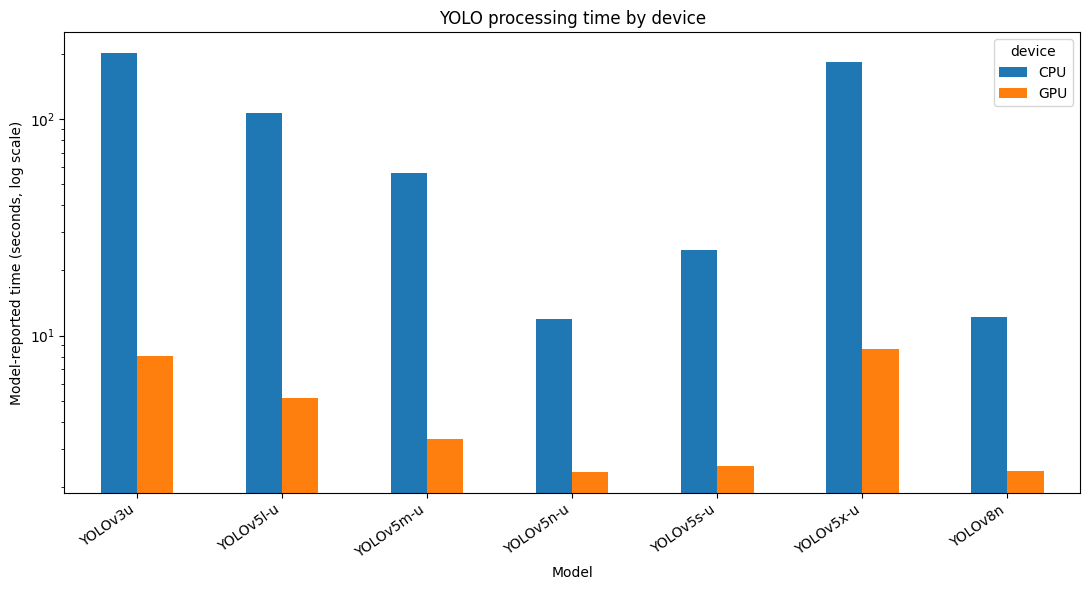

In [7]:
if not results.empty:
    pivot = results.pivot(index="model", columns="device", values="model_time_seconds")
    ax = pivot.plot(kind="bar", figsize=(11, 6), logy=True)
    ax.set_title("YOLO processing time by device")
    ax.set_ylabel("Model-reported time (seconds, log scale)")
    ax.set_xlabel("Model")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()